In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [4]:
x, y = make_classification(n_samples=5000, n_features=25, n_classes=2, random_state=42)

col_names = [f"feature_{i}" for i in range(1, 26)]

In [5]:
df = pd.DataFrame(x, columns=col_names)
df["target"] = y

df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,target
0,0.258644,1.668072,-0.703763,1.333868,1.279369,-1.116808,-0.423940,0.492090,-0.012931,0.181343,...,1.462643,0.731380,0.520208,-0.207005,-1.373260,-0.994034,-0.580801,-0.802468,0.750149,1
1,-1.577178,1.415001,0.490232,-0.810631,1.283733,0.844892,-2.567362,1.015660,0.156294,-1.686923,...,0.115598,0.081279,0.449728,0.371994,-2.061625,1.019160,-2.154458,0.764067,-0.097153,1
2,-1.605126,-1.318258,-1.814164,-1.694016,1.248737,-0.980176,-0.319133,0.737099,1.914775,-0.866383,...,0.746642,-0.999219,-0.314978,0.418495,0.297358,-1.495154,1.656717,0.749633,1.125282,0
3,-0.005793,-0.383887,0.472768,-1.299089,-0.619856,0.025882,0.059174,1.485156,-0.271290,0.246457,...,-1.064920,-0.216788,-0.133564,0.144863,1.442657,1.213379,-0.080180,-0.397923,0.955967,0
4,-0.175097,0.175514,-0.305185,-0.747285,0.470088,0.220328,0.626266,-0.398772,0.281375,0.084889,...,0.699728,-0.235143,0.069008,-1.548912,-2.574331,1.240427,0.511271,-2.496010,0.022554,1


In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.20, random_state=42)

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [12]:
pca = PCA(n_components=0.95)

x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

print("Original feature dimension:", x_train.shape[1])
print("Reduced feature dimension:", x_train_pca.shape[1])
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Original feature dimension: 25
Reduced feature dimension: 22
Total explained variance: 0.9669227928773623


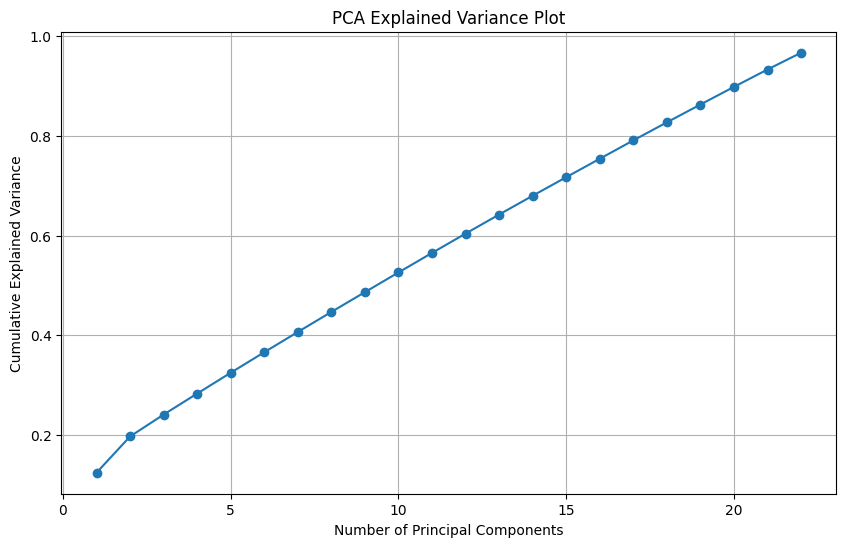

In [13]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance Plot")
plt.grid(True)
plt.show()